## Directing the algorithm

We can make some assumptions about out thigh segmentation. It should only happpen on human anatomy, which should be surrounded by air in any normal MRI. We can therefore first find the body and direct the algorithms to process only there. We will use the fat fraction slices to demo this as they are the "hardest case"

# Local Std Map — Edge Detection on Fat Fraction

Runs `local_std_map` on Dixon fat-fraction stacks.
High local standard deviation marks boundaries between tissue regions (edges).

In [1]:
import os
import glob

import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

from dissector.diffusion import local_std_map
from dissector.diffusion import find_body_oval


In [2]:
DATA_ROOT = 'myosegmenTUM'

ff_files = sorted(glob.glob(
    os.path.join(DATA_ROOT, '*', 'ImageData', '*_FATFRACTION', '*_FATFRACTION_stack1.nii')
))
print(f'Fat fraction stacks found: {len(ff_files)}')

ff_path = ff_files[0]
print(f'Using: {ff_path}')

Fat fraction stacks found: 25
Using: myosegmenTUM\HV001_1\ImageData\HV001_1_FATFRACTION\HV001_1_FATFRACTION_stack1.nii


In [3]:
ff_arr = sitk.GetArrayFromImage(sitk.ReadImage(ff_path)).astype(float)
print(f'Shape: {ff_arr.shape}  min={ff_arr.min():.1f}  max={ff_arr.max():.1f}')

Shape: (65, 672, 672)  min=-100.0  max=200.0


In [4]:
# run local_std_map on a 3-slice slab around the midpoint (fast)
mid  = ff_arr.shape[0] // 2
slab = ff_arr[mid - 1 : mid + 2]

std_map = local_std_map(slab, kernel_size=5)
std_slice = std_map[1]   # centre slice
ff_slice  = ff_arr[mid]

print(f'Std map  mean={std_slice.mean():.2f}  max={std_slice.max():.2f}')

Std map  mean=8.96  max=135.22


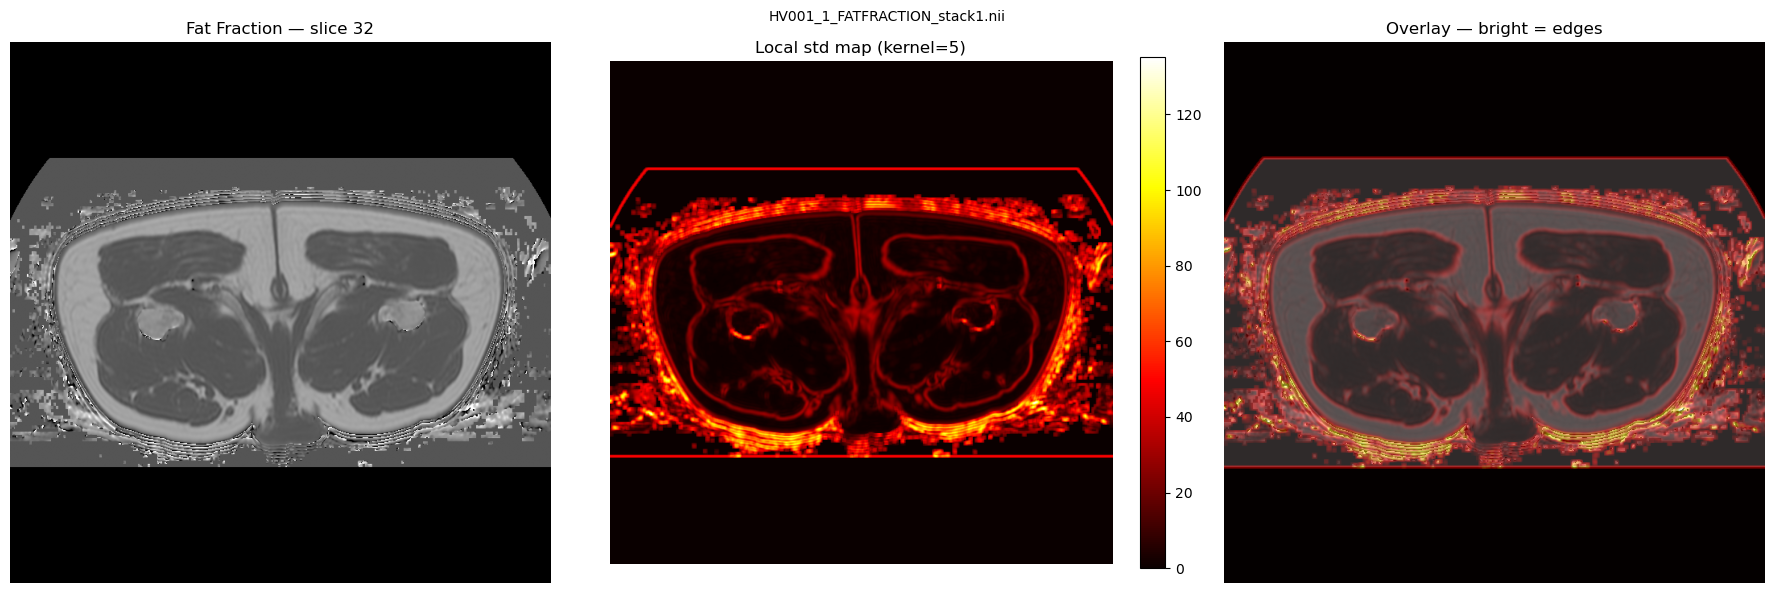

In [5]:
ff_norm  = (ff_slice  - ff_slice.min())  / (ff_slice.max()  - ff_slice.min()  + 1e-8)
std_norm = (std_slice - std_slice.min()) / (std_slice.max() - std_slice.min() + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(ff_norm, cmap='gray', origin='lower')
axes[0].set_title(f'Fat Fraction — slice {mid}')
axes[0].axis('off')

im = axes[1].imshow(std_slice, cmap='hot', origin='lower')
axes[1].set_title('Local std map (kernel=5)')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)

axes[2].imshow(ff_norm, cmap='gray', origin='lower')
axes[2].imshow(std_norm, cmap='hot', alpha=0.5, origin='lower')
axes[2].set_title('Overlay — bright = edges')
axes[2].axis('off')

plt.suptitle(os.path.basename(ff_path), fontsize=10)
plt.tight_layout()
plt.show()

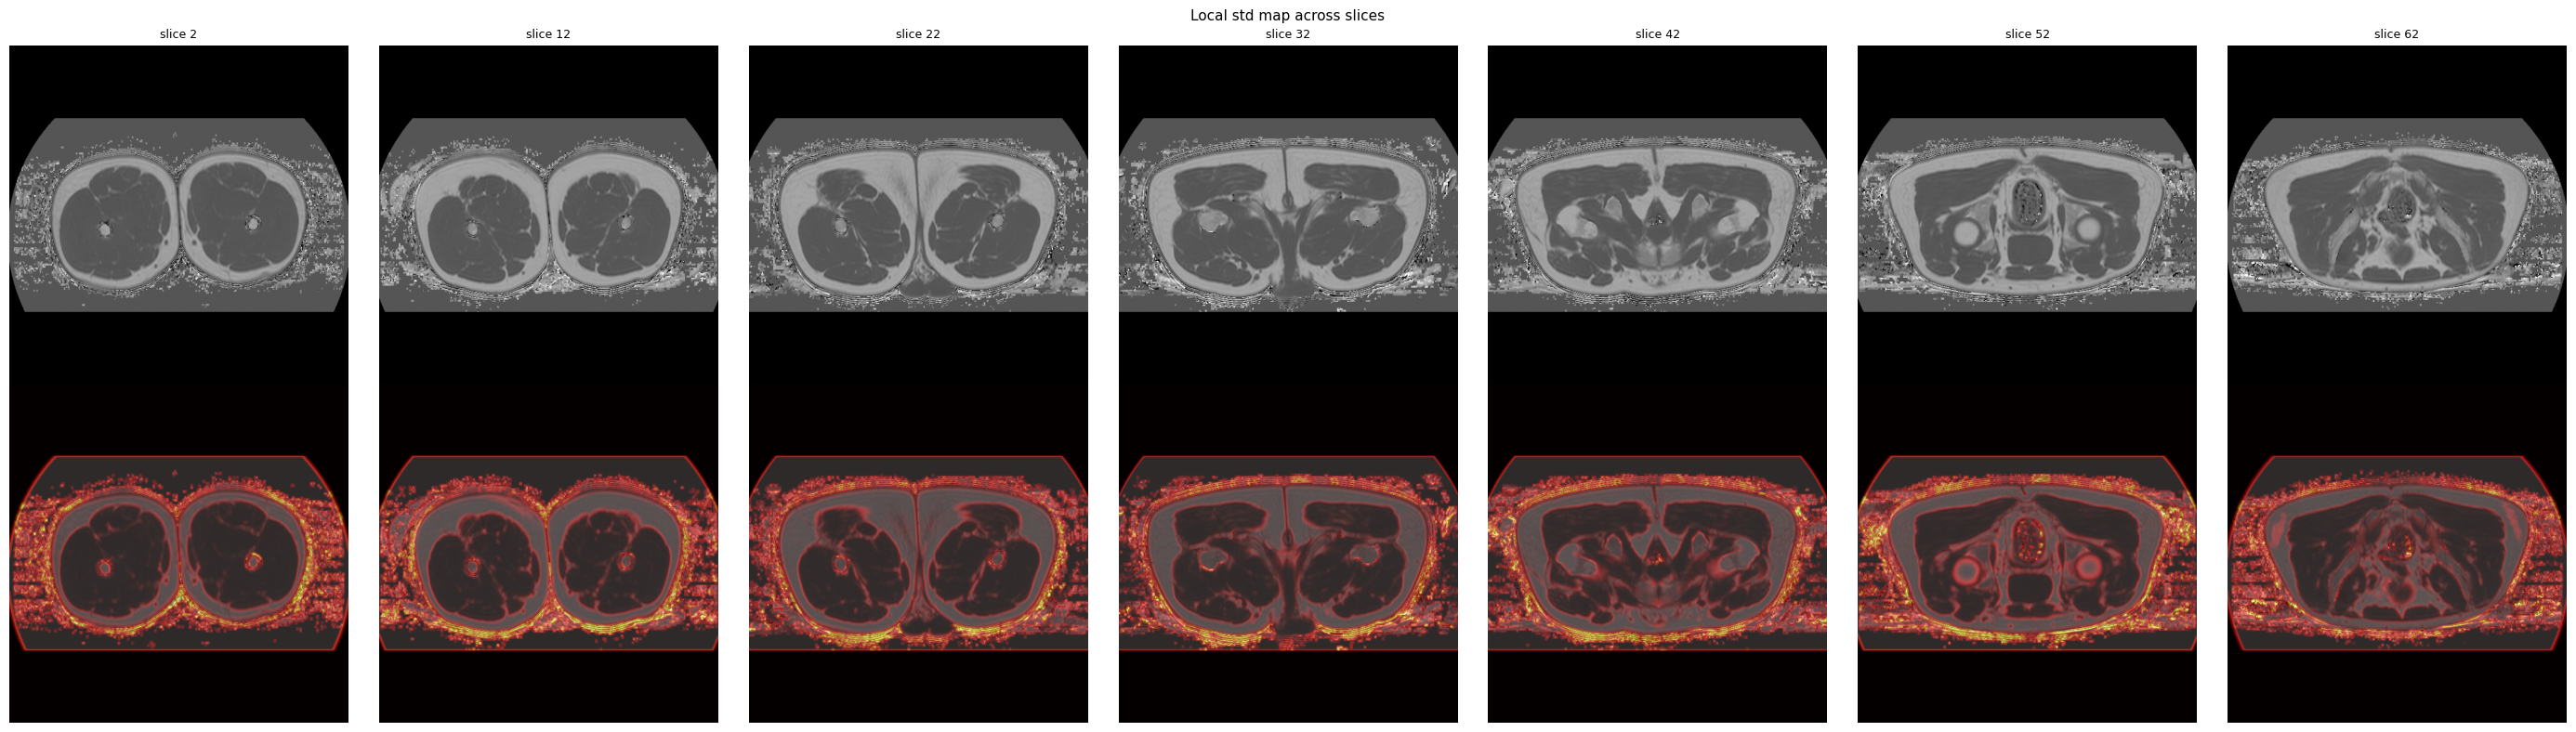

In [6]:
# scroll through several slices
slices = range(2, ff_arr.shape[0] - 2, max(1, ff_arr.shape[0] // 6))
n = len(list(slices))

fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))

for col, s in enumerate(slices):
    slab_s   = ff_arr[s - 1 : s + 2]
    std_s    = local_std_map(slab_s, kernel_size=5)[1]
    ff_s     = ff_arr[s]
    ff_n     = (ff_s  - ff_s.min())  / (ff_s.max()  - ff_s.min()  + 1e-8)
    std_n    = (std_s - std_s.min()) / (std_s.max() - std_s.min() + 1e-8)

    axes[0, col].imshow(ff_n,  cmap='gray', origin='lower')
    axes[0, col].set_title(f'slice {s}', fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(ff_n,  cmap='gray', origin='lower')
    axes[1, col].imshow(std_n, cmap='hot',  alpha=0.5, origin='lower')
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Fat fraction', fontsize=9)
axes[1, 0].set_ylabel('+ edge map',   fontsize=9)

plt.suptitle('Local std map across slices', fontsize=11)
plt.tight_layout()
plt.show()

## `find_body_oval`

Uses the edge map to locate the body cross-section:
1. Threshold the local-std map → binary edge ring
2. Close gaps → fill interior
3. Drop any region touching the image border (noise / table)
4. Largest surviving region = body; fit an ellipse via PCA

In [7]:
body_mask, contour = find_body_oval(ff_slice, kernel_size=5, edge_percentile=75)

print(f'Body voxels   : {body_mask.sum()}  ({100*body_mask.mean():.1f}% of slice)')
print(f'Contour pixels: {contour.sum()}')

Body voxels   : 208631  (46.2% of slice)
Contour pixels: 2768


## The body mask

1. Edge map — `generic_filter` computes local standard deviation over a `kernel_size×kernel_size` neighbourhood. Tissue boundaries produce high values.

2. Binarise — pixels above the `edge_percentile` (default 75th) of the std map become `True` — these are the detected edges.

3. Close gaps — `binary_closing` with `closing_iterations=4` bridges small breaks in the edge ring so it forms a closed loop.

4. Fill interior — `binary_fill_holes` floods the enclosed area, producing solid filled blobs.

5. Label components — `ndlabel` finds all separate connected regions.

6. Discard border-touching regions — any component whose pixels touch the top, bottom, left, or right image border is thrown out (table surface, coil noise, air outside FOV).

7. Pick the largest survivor — the biggest remaining filled region is taken as the body.

8. Remove thin protrusions — `binary_opening` (erode then dilate) cleans up stray lines and spurs left on the body mask before tracing the boundary.

9. Contour — `body_mask & ~binary_erosion(body_mask)` gives the 1-pixel-wide boundary of that region.

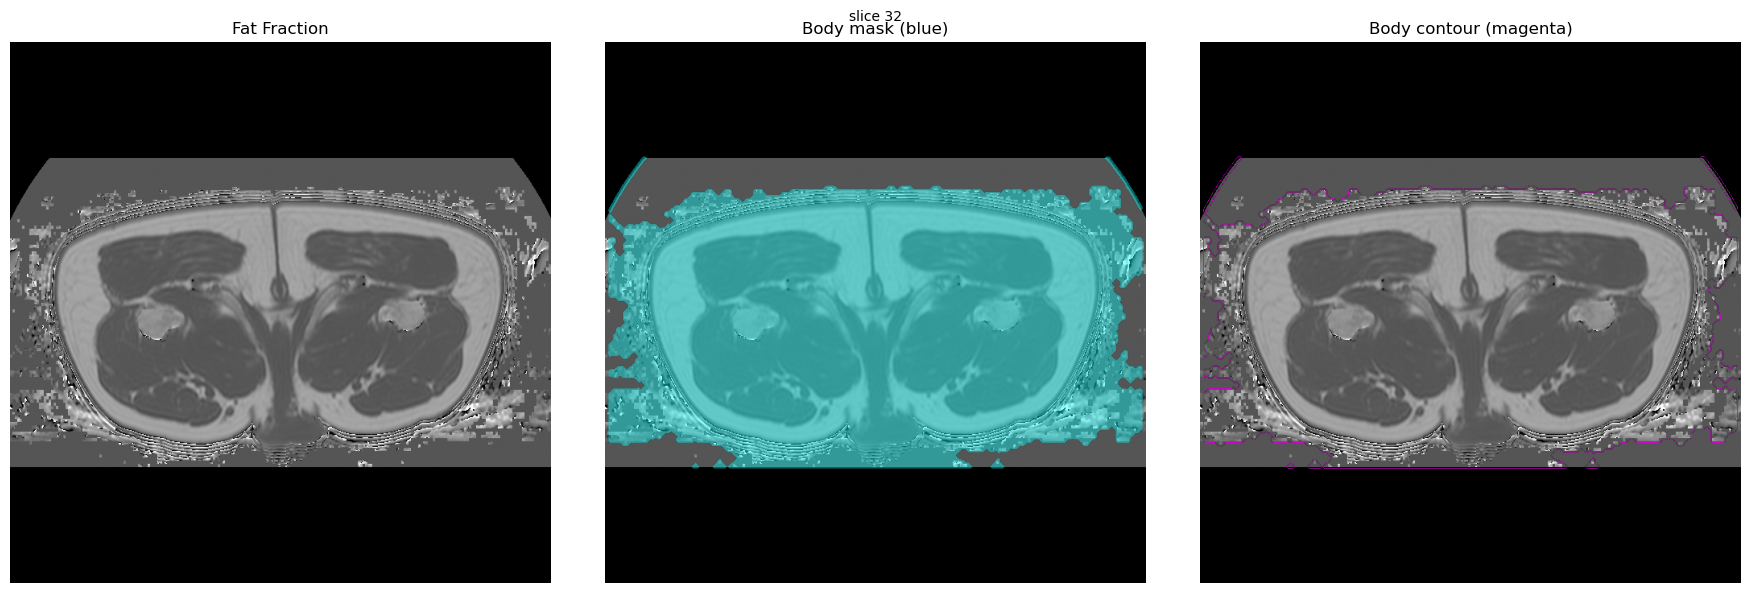

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# panel 1 — fat fraction
axes[0].imshow(ff_norm, cmap='gray', origin='lower')
axes[0].set_title('Fat Fraction')
axes[0].axis('off')

# panel 2 — body mask
axes[1].imshow(ff_norm, cmap='gray', origin='lower')
axes[1].imshow(np.ma.masked_where(~body_mask, body_mask), cmap='cool', alpha=0.4, origin='lower')
axes[1].set_title('Body mask (blue)')
axes[1].axis('off')

# panel 3 — contour overlay (actual tissue boundary from local_std edges)
axes[2].imshow(ff_norm, cmap='gray', origin='lower')
if contour.any():
    axes[2].imshow(np.ma.masked_where(~contour, contour), cmap='spring', alpha=1.0, origin='lower')
axes[2].set_title('Body contour (magenta)')
axes[2].axis('off')

plt.suptitle(f'slice {mid}', fontsize=10)
plt.tight_layout()
plt.show()

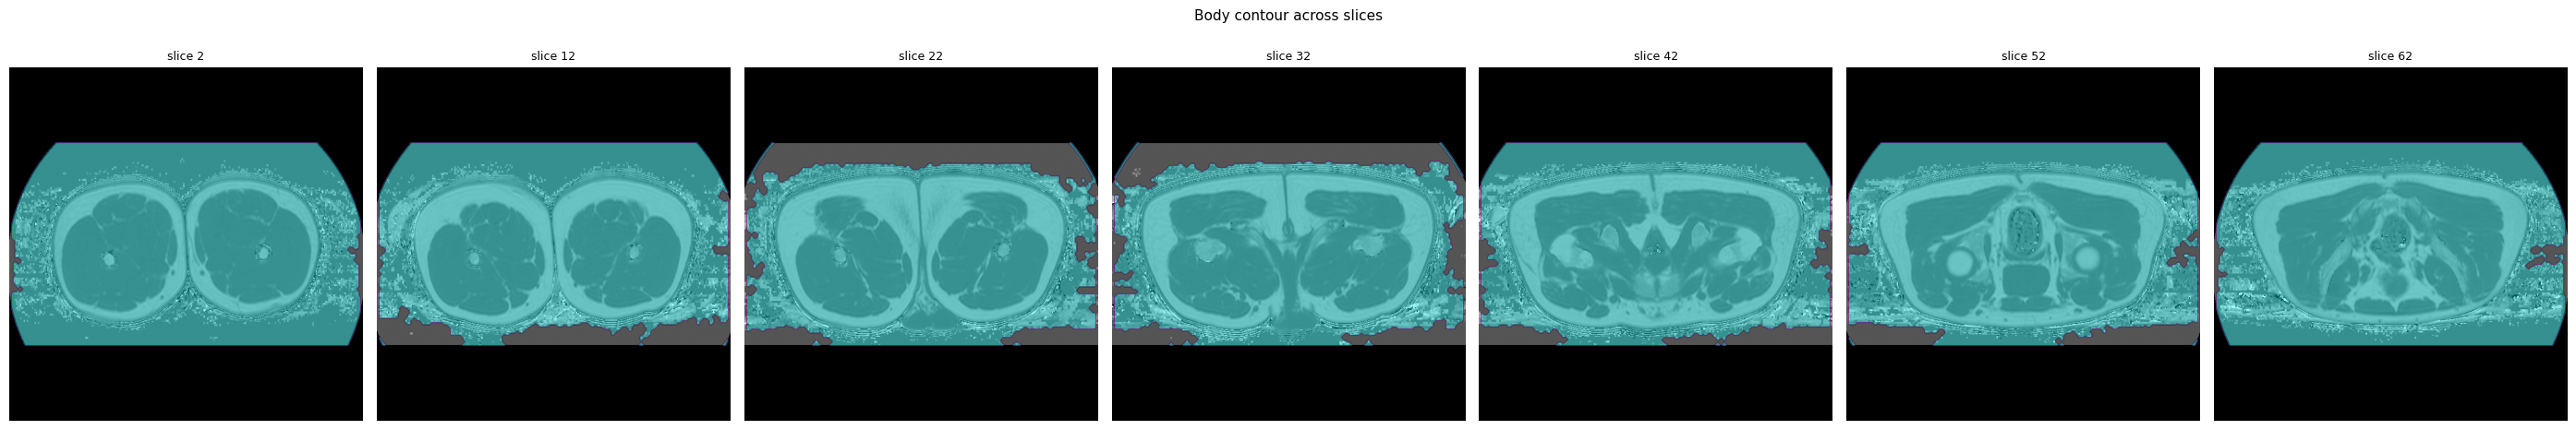

In [9]:
# show body contour across several slices
slices = range(2, ff_arr.shape[0] - 2, max(1, ff_arr.shape[0] // 6))
n = len(list(slices))

fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))

for ax, s in zip(axes, slices):
    sl   = ff_arr[s]
    sl_n = (sl - sl.min()) / (sl.max() - sl.min() + 1e-8)
    mask, contour_s = find_body_oval(sl, kernel_size=5, edge_percentile=75)

    ax.imshow(sl_n, cmap='gray', origin='lower')
    ax.imshow(np.ma.masked_where(~mask, mask), cmap='cool', alpha=0.35, origin='lower')
    if contour_s.any():
        ax.imshow(np.ma.masked_where(~contour_s, contour_s), cmap='spring', alpha=1.0, origin='lower')

    ax.set_title(f'slice {s}', fontsize=9)
    ax.axis('off')

plt.suptitle('Body contour across slices', fontsize=11)
plt.tight_layout()
plt.show()

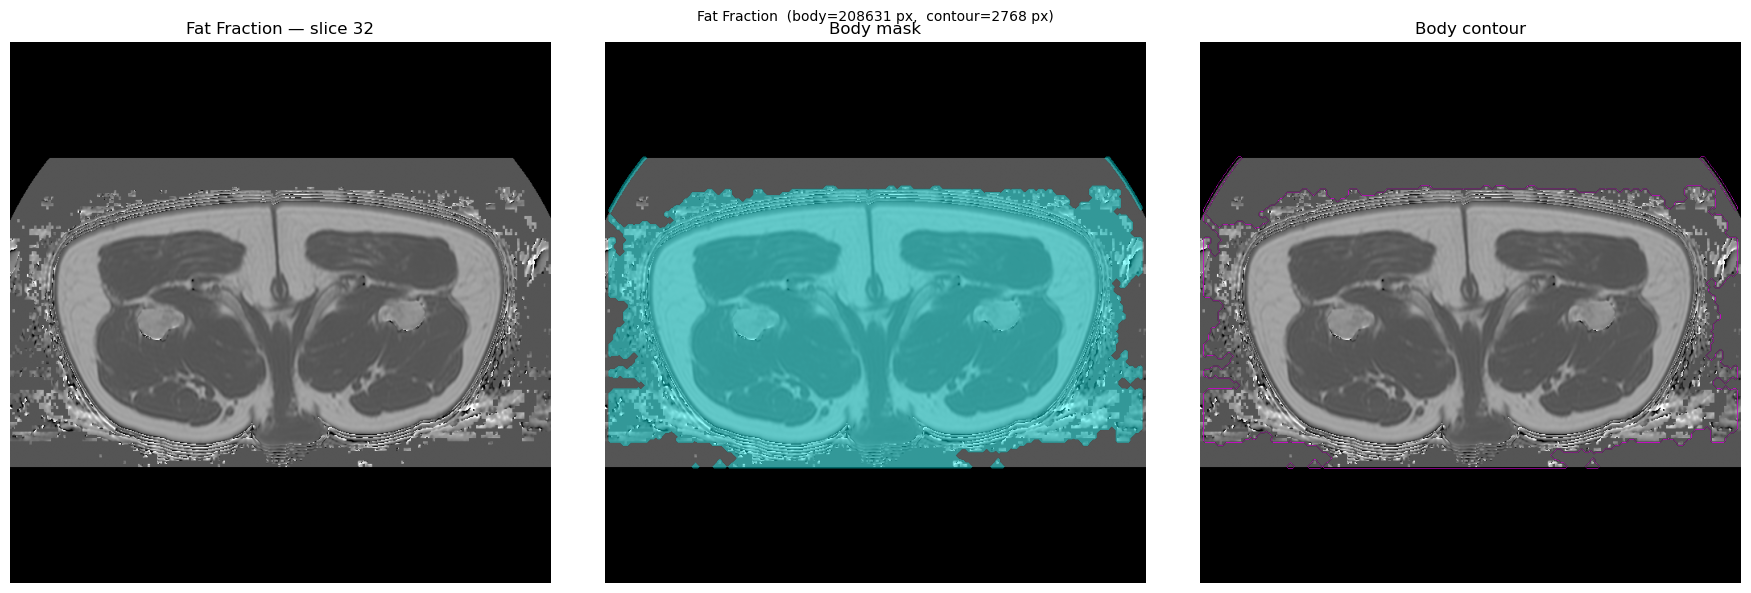

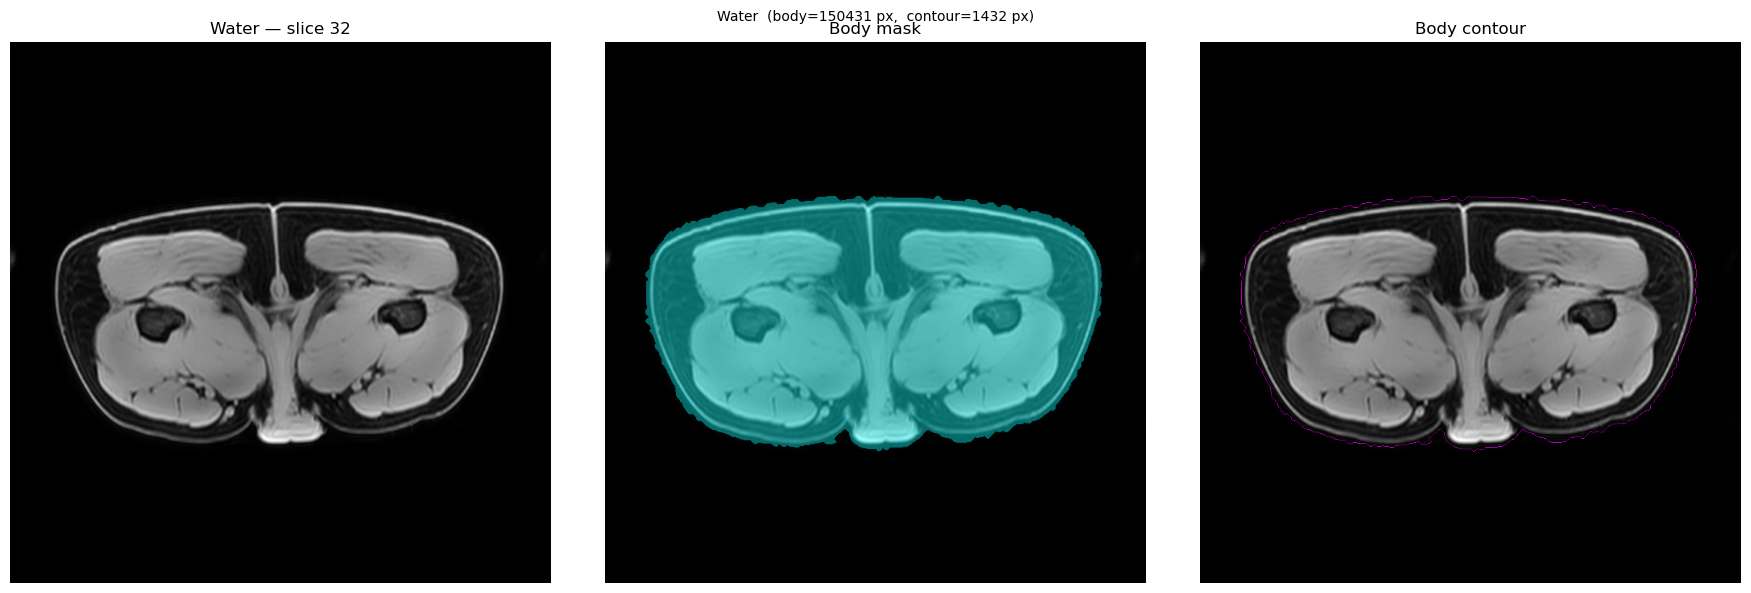

In [10]:
# compare body contour on fat fraction vs water for the same subject
water_path = ff_path.replace('FATFRACTION', 'WATER')
water_arr  = sitk.GetArrayFromImage(sitk.ReadImage(water_path)).astype(float)

for label, arr in [('Fat Fraction', ff_arr), ('Water', water_arr)]:
    mid_s = arr.shape[0] // 2
    sl    = arr[mid_s]
    sl_n  = (sl - sl.min()) / (sl.max() - sl.min() + 1e-8)
    mask, contour_sl = find_body_oval(sl, kernel_size=5, edge_percentile=75)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(sl_n, cmap='gray', origin='lower')
    axes[0].set_title(f'{label} — slice {mid_s}')
    axes[0].axis('off')

    axes[1].imshow(sl_n, cmap='gray', origin='lower')
    axes[1].imshow(np.ma.masked_where(~mask, mask), cmap='cool', alpha=0.4, origin='lower')
    axes[1].set_title('Body mask')
    axes[1].axis('off')

    axes[2].imshow(sl_n, cmap='gray', origin='lower')
    if contour_sl.any():
        axes[2].imshow(np.ma.masked_where(~contour_sl, contour_sl), cmap='spring', alpha=1.0, origin='lower')
    axes[2].set_title('Body contour')
    axes[2].axis('off')

    plt.suptitle(f'{label}  (body={mask.sum()} px,  contour={contour_sl.sum()} px)', fontsize=10)
    plt.tight_layout()
    plt.show()

# So we can see this will work much better on a water image...but the idea will hold across any- we will direct our algorithms toward the tissue only!